In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

**Load the dataset**

**part 1: File I/O with Pandas**

In [2]:
import pandas as pd
df = pd.read_csv("Reviews.csv", nrows=500)
print(df.shape)

(500, 10)


In [3]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Id                      500 non-null    int64 
 1   ProductId               500 non-null    object
 2   UserId                  500 non-null    object
 3   ProfileName             500 non-null    object
 4   HelpfulnessNumerator    500 non-null    int64 
 5   HelpfulnessDenominator  500 non-null    int64 
 6   Score                   500 non-null    int64 
 7   Time                    500 non-null    int64 
 8   Summary                 500 non-null    object
 9   Text                    500 non-null    object
dtypes: int64(5), object(5)
memory usage: 39.2+ KB


**PART 2: DataFrame Operations**

**Indexing**

In [5]:
df['Text'].head()
df[['Text', 'Score']].head()

,Text,Score
0,I have bought several of the Vitality canned d...,5
1,Product arrived labeled as Jumbo Salted Peanut...,1
2,This is a confection that has been around a fe...,4
3,If you are looking for the secret ingredient i...,2
4,Great taffy at a great price. There was a wid...,5


**Filtering**

In [6]:
positive_df = df[df['Score'] >= 4]
negative_df = df[df['Score'] <= 2]

**Sorting**

In [7]:
df_sorted = df.sort_values(by='Score', ascending=False)

**Grouping**

In [8]:
df.groupby('Score')['Text'].count()

,Text
Score,
1,36
2,18
3,37
4,70
5,339


**Create New Column**

In [9]:
df['text_length'] = df['Text'].apply(len)

In [10]:
df['text_length']

,text_length
0,263
1,190
2,509
3,219
4,140
...,...
495,176
496,364
497,842
498,209


**String operations**

In [11]:
df['Text_lower'] = df['Text'].str.lower()

**PART 3: Descriptive Statistics**

In [12]:
df.describe()

,Id,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,text_length
count,500.000000,500.000000,500.00000,500.000000,5.000000e+02,500.000000
mean,250.500000,0.952000,1.27600,4.316000,1.294820e+09,369.464000
std,144.481833,2.045988,2.48922,1.202929,5.072437e+07,321.500223
min,1.000000,0.000000,0.00000,1.000000,1.107821e+09,57.000000
25%,125.750000,0.000000,0.00000,4.000000,1.267790e+09,171.750000
50%,250.500000,0.000000,0.00000,5.000000,1.312978e+09,257.500000
75%,375.250000,1.000000,2.00000,5.000000,1.334621e+09,454.250000
max,500.000000,19.000000,19.00000,5.000000,1.351210e+09,2308.000000


In [13]:
df['word_count'] = df['Text'].apply(lambda x: len(x.split()))

In [14]:
df['word_count']

,word_count
0,48
1,31
2,94
3,41
4,27
...,...
495,33
496,65
497,148
498,35


In [15]:
# Character count
df['char_count'] = df['Text'].apply(len)

In [16]:
# Average text length
print("Average words:", df['word_count'].mean())

Average words: 68.158


In [17]:
# Vocabulary size
all_words = " ".join(df['Text']).split()
vocab = set(all_words)
print("Vocabulary size:", len(vocab))

Vocabulary size: 6765


In [18]:
# Top frequent words

common_words = Counter(all_words).most_common(10)
print(common_words)

[('the', 1279), ('and', 986), ('I', 978), ('a', 884), ('to', 704), ('of', 595), ('is', 553), ('it', 409), ('for', 407), ('in', 390)]


In [19]:
# Missing percentage
missing = df['Text'].isnull().mean() * 100
print("Missing %:", missing)

Missing %: 0.0


**PART 4: Text Preprocessing**

In [20]:
# Setup tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [21]:
def preprocess(text):
    if pd.isnull(text):
        return ""

    # 1. Lowercase
    text = text.lower()

    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # 3. Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # 4. Remove punctuation & numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # 5. Normalize whitespace
    text = " ".join(text.split())

    # 6. Tokenization
    tokens = text.split()

    # 7. Remove stopwords
    tokens = [w for w in tokens if w not in stop_words]

    # 8. Lemmatization
    tokens = [lemmatizer.lemmatize(w) for w in tokens]

    # 9. Filter short words
    tokens = [w for w in tokens if len(w) > 2]

    return " ".join(tokens)

In [22]:
df['clean_text'] = df['Text'].apply(preprocess)

In [23]:
df.to_csv("cleaned_reviews.csv", index=False)

**PART 5: Data Visualization**

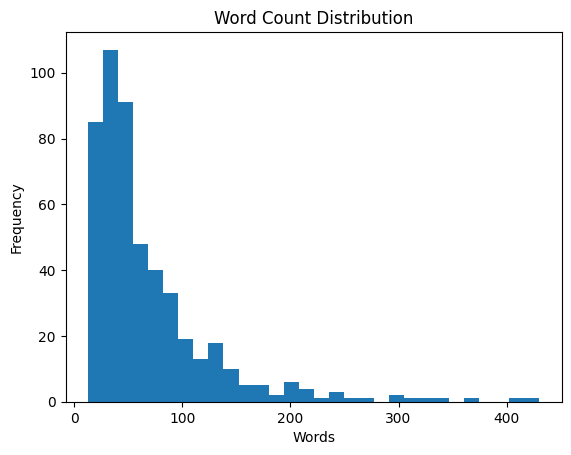

In [24]:
plt.hist(df['word_count'], bins=30)
plt.title("Word Count Distribution")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

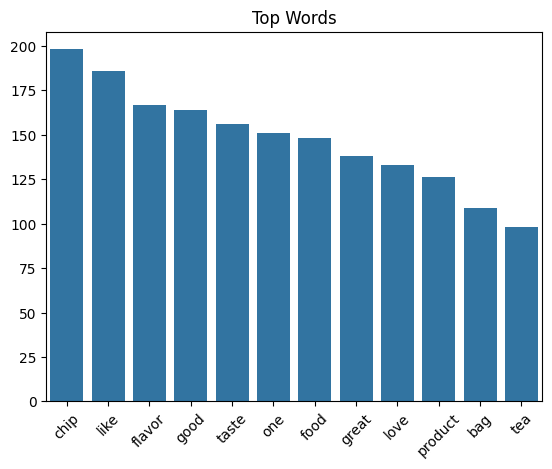

In [25]:
clean_words = " ".join(df['clean_text']).split()
top_words = Counter(clean_words).most_common(12)

words, counts = zip(*top_words)

sns.barplot(x=list(words), y=list(counts))
plt.xticks(rotation=45)
plt.title("Top Words")
plt.show()

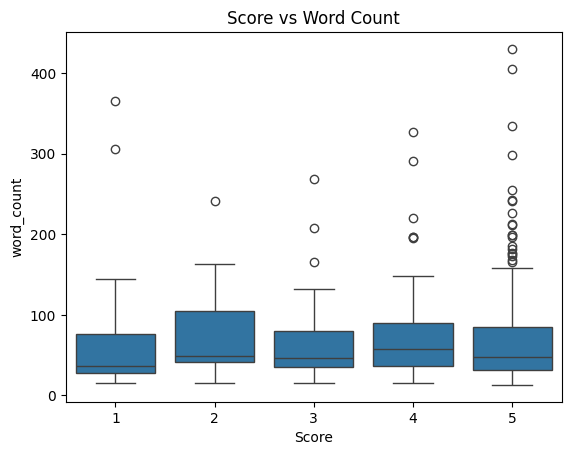

In [26]:
sns.boxplot(x='Score', y='word_count', data=df)
plt.title("Score vs Word Count")
plt.show()

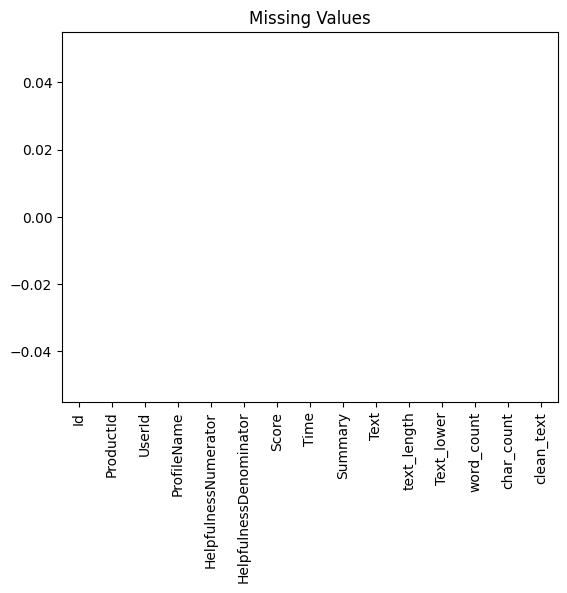

In [27]:
df.isnull().sum().plot(kind='bar')
plt.title("Missing Values")
plt.show()

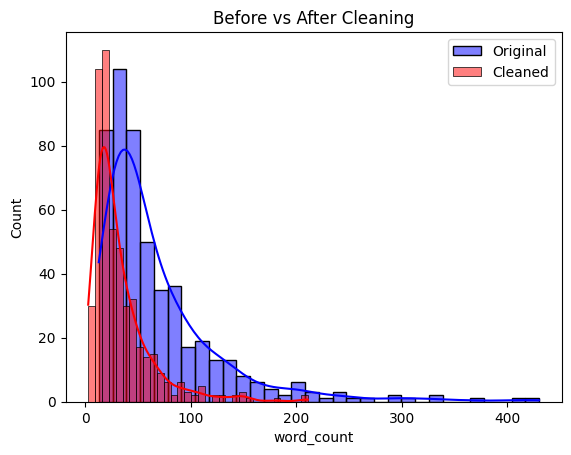

In [28]:
df['clean_length'] = df['clean_text'].apply(lambda x: len(x.split()))

sns.histplot(df['word_count'], color='blue', label='Original', kde=True)
sns.histplot(df['clean_length'], color='red', label='Cleaned', kde=True)

plt.legend()
plt.title("Before vs After Cleaning")
plt.show()

In [29]:
def get_sentiment(score):
    if score <= 2:
        return "negative"
    elif score == 3:
        return "neutral"
    else:
        return "positive"

df['sentiment'] = df['Score'].apply(get_sentiment)

In [31]:
df['avg_word_length'] = df['char_count'] / df['word_count']

df['stopword_count'] = df['Text'].apply(
    lambda x: len([w for w in x.lower().split() if w in stop_words])
)

df['uppercase_count'] = df['Text'].apply(
    lambda x: sum(1 for c in x if c.isupper())
)

In [33]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(ngram_range=(2,2), max_features=10)
ngrams = vectorizer.fit_transform(df['clean_text'])

print(vectorizer.get_feature_names_out())

['dog food' 'energy shot' 'grocery store' 'highly recommend'
 'kettle brand' 'kettle chip' 'much better' 'potato chip' 'salt vinegar'
 'taste good']


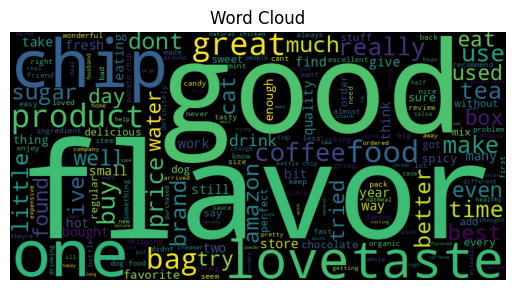

In [34]:
from wordcloud import WordCloud

text = " ".join(df['clean_text'])

wordcloud = WordCloud(width=800, height=400).generate(text)

plt.imshow(wordcloud)
plt.axis('off')
plt.title("Word Cloud")
plt.show()

In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=1000)

X = tfidf.fit_transform(df['clean_text'])

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X, df['sentiment'], test_size=0.2, random_state=42
)

model = LogisticRegression()
model.fit(X_train, y_train)

preds = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))

Accuracy: 0.81


In [37]:
import pickle

# save model
pickle.dump(model, open("model.pkl", "wb"))

# save tfidf
pickle.dump(tfidf, open("tfidf.pkl", "wb"))

In [39]:
from google.colab import files

files.download("model.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [41]:
files.download("tfidf.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>